In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../cleaned_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (51290, 23)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
print("Dataset Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

Dataset Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      512

In [4]:
numeric_features = df.select_dtypes(include=np.number).columns

print("Numerical Features:")
print(numeric_features.tolist())

Numerical Features:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin']


In [5]:
X = df[numeric_features].copy()

print("Features selected for PCA:")
print(X.columns.tolist())

print("\nShape of feature data:")
print(X.shape)

Features selected for PCA:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin']

Shape of feature data:
(51290, 8)


In [6]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
sales            0
quantity         0
discount         0
profit           0
shipping_cost    0
year             0
shipping_days    0
profit_margin    0
dtype: int64


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Standardized shape:", X_scaled.shape)

Original shape: (51290, 8)
Standardized shape: (51290, 8)


In [8]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of PCA components:", X_pca_full.shape[1])

Original number of features: 8
Number of PCA components: 8


In [9]:
explained_variance = pca_full.explained_variance_ratio_

for i, variance in enumerate(explained_variance):
    print(f"PC{i+1}: {variance:.4f} ({variance*100:.2f}%)")

PC1: 0.3083 (30.83%)
PC2: 0.2168 (21.68%)
PC3: 0.1273 (12.73%)
PC4: 0.1249 (12.49%)
PC5: 0.1085 (10.85%)
PC6: 0.0702 (7.02%)
PC7: 0.0254 (2.54%)
PC8: 0.0187 (1.87%)


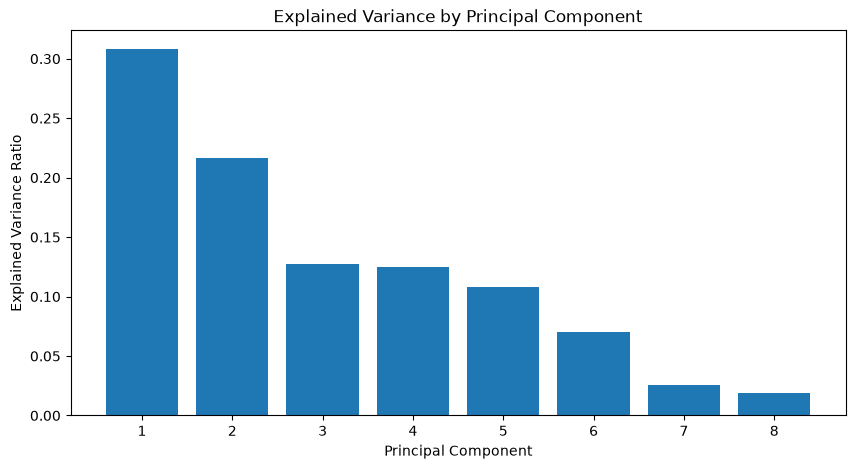

In [10]:
components = range(1, len(explained_variance) + 1)

plt.figure(figsize=(10, 5))

plt.bar(components, explained_variance)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")

plt.xticks(components)

plt.show()

First 1 components: 0.3083 (30.83%)
First 2 components: 0.5251 (52.51%)
First 3 components: 0.6523 (65.23%)
First 4 components: 0.7772 (77.72%)
First 5 components: 0.8856 (88.56%)
First 6 components: 0.9559 (95.59%)
First 7 components: 0.9813 (98.13%)
First 8 components: 1.0000 (100.00%)


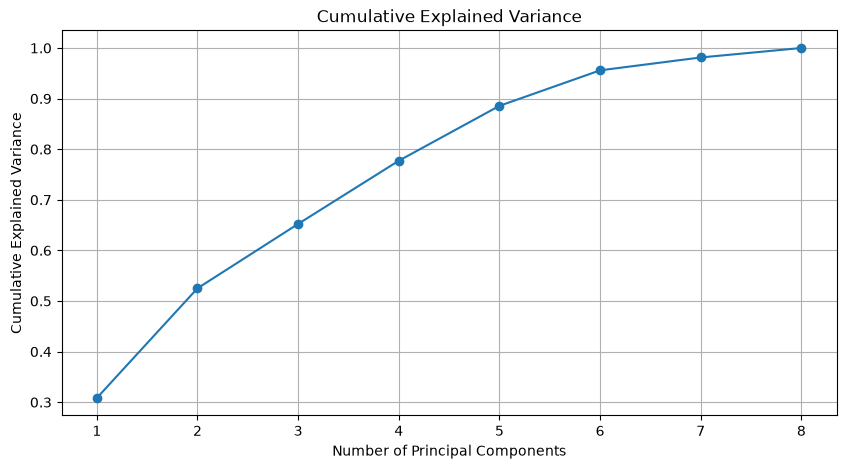

In [12]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Create component numbers
components = range(1, len(explained_variance) + 1)

# Display values
for i, variance in enumerate(cumulative_variance):
    print(
        f"First {i+1} components: "
        f"{variance:.4f} ({variance*100:.2f}%)"
    )

# Plot cumulative variance
plt.figure(figsize=(10, 5))

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.xticks(components)
plt.grid(True)

plt.show()

In [13]:
# Apply PCA with 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original data shape:", X.shape)
print("Reduced data shape:", X_pca.shape)

Original data shape: (51290, 8)
Reduced data shape: (51290, 2)


In [14]:
# Create a DataFrame containing the PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("PCA Data:")
display(pca_df.head())

PCA Data:


,PC1,PC2
0,0.683389,0.636261
1,-0.081659,0.801887
2,0.316860,1.042693
3,-1.717594,-1.341950
4,0.112234,0.652681


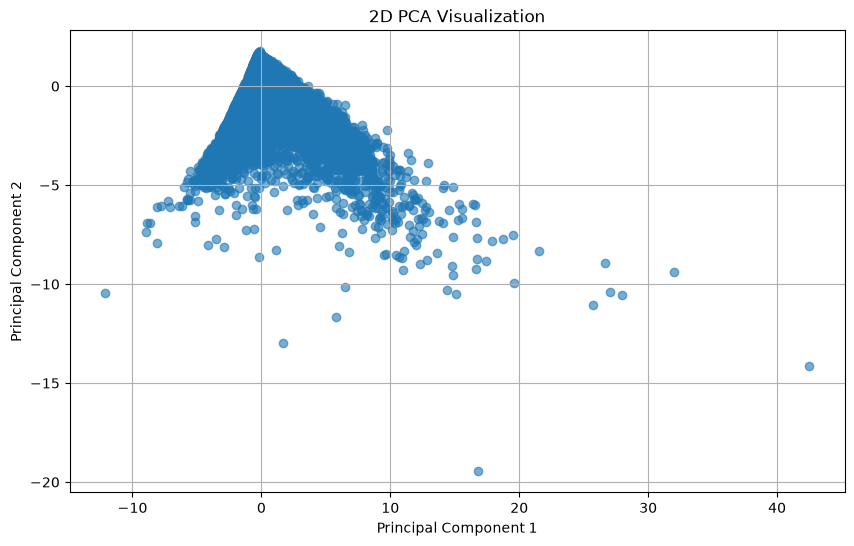

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization")
plt.grid(True)

plt.show()

In [16]:
if "Profit" in df.columns:
    y = (df["Profit"] > 0).astype(int)

    print("Target variable created successfully.")
    print("\nTarget distribution:")
    print(y.value_counts())
else:
    print("Profit column was not found.")

Profit column was not found.


In [19]:
print("Actual column names in the dataset:")

for col in df.columns:
    print(repr(col))

Actual column names in the dataset:
'order_id'
'order_date'
'ship_date'
'ship_mode'
'customer_name'
'segment'
'state'
'country'
'market'
'region'
'product_id'
'category'
'sub_category'
'product_name'
'sales'
'quantity'
'discount'
'profit'
'shipping_cost'
'order_priority'
'year'
'shipping_days'
'profit_margin'


In [20]:
print(df.columns.tolist())

['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


In [21]:
print("Columns in your dataset:")
print(df.columns.tolist())

Columns in your dataset:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


In [22]:
# Find possible target columns

print("All columns:")
print(df.columns.tolist())

print("\nNumeric columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

All columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']

Numeric columns:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin']


In [23]:
# Check numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns found:")
print(numeric_cols)

Numeric columns found:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin']


In [24]:
# Automatically find a target column

if "Profit" in df.columns:
    target_column = "Profit"
elif "Sales" in df.columns:
    target_column = "Sales"
else:
    target_column = df.select_dtypes(include=np.number).columns[-1]

print("Target column selected:", target_column)

y = (df[target_column] > df[target_column].median()).astype(int)

print("\nTarget variable created successfully.")
print(y.value_counts())

Target column selected: profit_margin

Target variable created successfully.
profit_margin
1    25645
0    25645
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (41032, 8)
Testing data shape: (10258, 8)
Training target shape: (41032,)
Testing target shape: (10258,)


In [26]:
# Logistic Regression before PCA

model_before = LogisticRegression(max_iter=1000)

model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

accuracy_before = accuracy_score(
    y_test,
    pred_before
)

print(f"Accuracy before PCA: {accuracy_before:.4f}")

Accuracy before PCA: 0.9958


In [27]:
# Apply PCA with 2 components

pca_model = PCA(n_components=2)

X_train_pca = pca_model.fit_transform(X_train)
X_test_pca = pca_model.transform(X_test)

print("Original training shape:", X_train.shape)
print("PCA training shape:", X_train_pca.shape)

print("Original testing shape:", X_test.shape)
print("PCA testing shape:", X_test_pca.shape)

Original training shape: (41032, 8)
PCA training shape: (41032, 2)
Original testing shape: (10258, 8)
PCA testing shape: (10258, 2)


In [28]:
# Logistic Regression after PCA

model_after = LogisticRegression(max_iter=1000)

model_after.fit(X_train_pca, y_train)

pred_after = model_after.predict(X_test_pca)

accuracy_after = accuracy_score(
    y_test,
    pred_after
)

print(f"Accuracy after PCA: {accuracy_after:.4f}")

Accuracy after PCA: 0.8378


In [29]:
# Logistic Regression after PCA

model_after = LogisticRegression(max_iter=1000)

model_after.fit(X_train_pca, y_train)

pred_after = model_after.predict(X_test_pca)

accuracy_after = accuracy_score(
    y_test,
    pred_after
)

print(f"Accuracy after PCA: {accuracy_after:.4f}")

Accuracy after PCA: 0.8378


In [30]:
# Compare model performance before and after PCA

print("Model Performance Comparison")
print("----------------------------")

print(f"Accuracy before PCA: {accuracy_before:.4f}")
print(f"Accuracy after PCA : {accuracy_after:.4f}")

difference = accuracy_after - accuracy_before

print(f"\nAccuracy difference: {difference:.4f}")

Model Performance Comparison
----------------------------
Accuracy before PCA: 0.9958
Accuracy after PCA : 0.8378

Accuracy difference: -0.1580


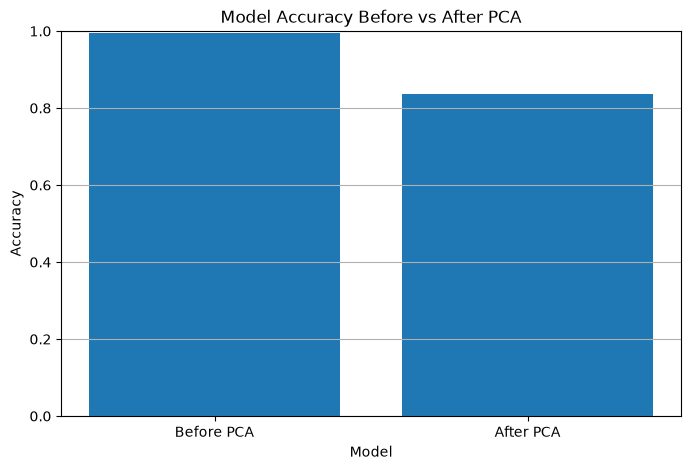

In [31]:
# Visualize model accuracy before and after PCA

labels = ["Before PCA", "After PCA"]
accuracies = [accuracy_before, accuracy_after]

plt.figure(figsize=(8, 5))

plt.bar(labels, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Before vs After PCA")

plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

In [32]:
# PCA explained variance analysis

variance_table = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Explained Variance": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

display(variance_table)

,Principal Component,Explained Variance,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.308326,30.832558,30.832558
1,PC2,0.216765,21.676508,52.509066
2,PC3,0.127253,12.725267,65.234332
3,PC4,0.124850,12.485015,77.719347
4,PC5,0.108456,10.845562,88.564910
5,PC6,0.070205,7.020524,95.585433
6,PC7,0.025447,2.544656,98.130089
7,PC8,0.018699,1.869911,100.000000


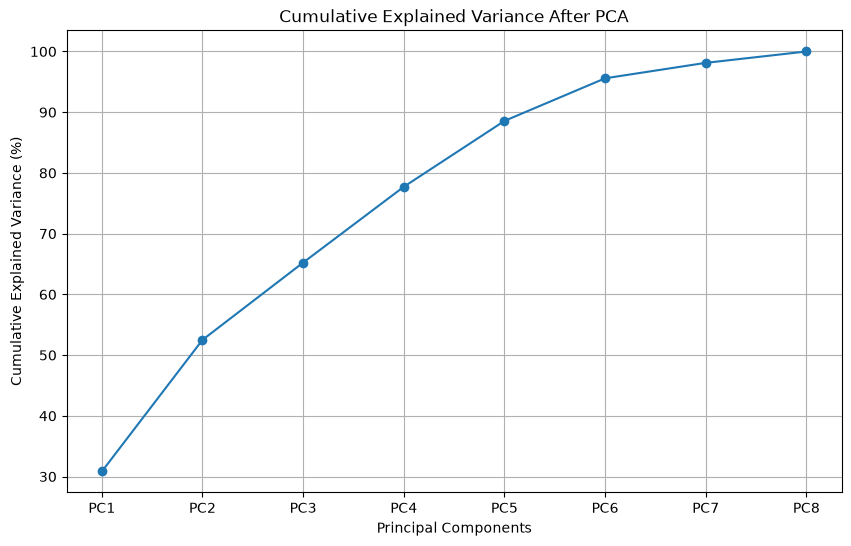

In [33]:
# Plot cumulative explained variance

plt.figure(figsize=(10, 6))

plt.plot(
    variance_table["Principal Component"],
    variance_table["Cumulative Variance (%)"],
    marker="o"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance After PCA")

plt.grid(True)

plt.show()

In [34]:
# Final PCA Summary

print("========== DAY 24 PCA SUMMARY ==========")

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features: 2")

print(
    f"\nVariance retained by PC1: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    f"Variance retained by PC2: "
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    f"Total variance retained by 2 PCs: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

print(f"\nAccuracy before PCA: {accuracy_before:.4f}")
print(f"Accuracy after PCA:  {accuracy_after:.4f}")

print(
    f"Accuracy difference: "
    f"{accuracy_after - accuracy_before:.4f}"
)

print("\n========================================")

========== DAY 24 PCA SUMMARY ==========
Original number of features: 8
Reduced number of features: 2

Variance retained by PC1: 30.83%
Variance retained by PC2: 21.68%
Total variance retained by 2 PCs: 52.51%

Accuracy before PCA: 0.9958
Accuracy after PCA:  0.8378
Accuracy difference: -0.1580

